# RETO REDES NEURONALES ECOM DATA
# ALUMNO : SU NOMBRE Y APELLIDO


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
data_df = pd.read_csv('/content/ecom_data_transformed.csv')
data_df

,gender,login_computer,login_mobile,login_phone,payment_cc,payment_cod,payment_cash,payment_credit,payment_debit,payment_ewallet,...,hour_spend,device_registered,satisfaction_score,number_address,complain,order_lastyear,coupon_used,order_count,days_lastorder,cashback_amount
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,3.0,3.0,2.0,9.0,1.0,11.0,1.0,1.0,5.0,160.0
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,4.0,3.0,7.0,1.0,15.0,0.0,1.0,0.0,121.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,2.0,4.0,3.0,6.0,1.0,14.0,0.0,1.0,3.0,120.0
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,2.0,4.0,5.0,8.0,0.0,23.0,0.0,1.0,3.0,134.0
4,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,3.0,3.0,5.0,3.0,0.0,11.0,1.0,1.0,3.0,130.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,3.0,2.0,1.0,6.0,0.0,18.0,1.0,2.0,4.0,151.0
5626,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,3.0,5.0,5.0,6.0,0.0,16.0,1.0,2.0,3.0,225.0
5627,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,3.0,2.0,4.0,3.0,1.0,21.0,1.0,2.0,4.0,186.0
5628,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,4.0,5.0,4.0,4.0,0.0,15.0,2.0,2.0,9.0,179.0


In [30]:
data_df.dtypes.value_counts()

,count
float64,34


In [31]:
data_df.isnull().sum().sum()

np.int64(0)

# CORRELACIONES

In [32]:
corr_matrix = data_df.corr()
corr_churn = corr_matrix['churn']
corr_churn.sort_values(ascending=False)

,churn
churn,1.000000
complain,0.250188
single,0.180847
order_mobile_phone,0.154387
order_phone,0.113364
device_registered,0.107939
satisfaction_score,0.105481
city_tier,0.084703
payment_cod,0.083933
login_phone,0.078916


## MAPA DE CALOR DE CORRELACIONES

<Axes: >

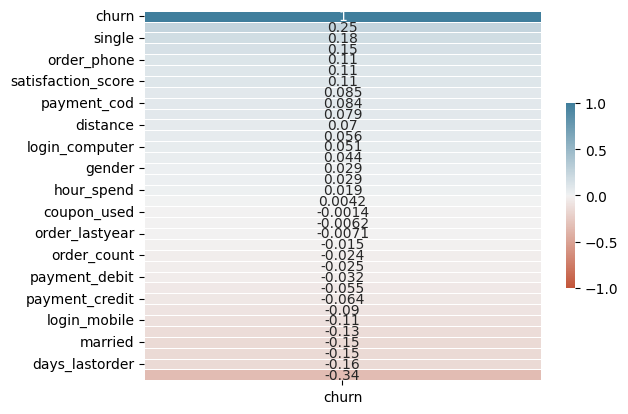

In [33]:
sns.heatmap(
    data=corr_churn.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

## FILTRAMOS POR VARIABLES QUE TENGAN UN CORRELACIÓN MAYOR A 0 Y MENOR A 1 CON CHURN

In [34]:
corr_filtered = corr_churn[(corr_churn >= 0) & (corr_churn < 1)]
corr_filtered
cols = corr_filtered.index.tolist()
cols

['gender',
 'login_computer',
 'login_phone',
 'payment_cc',
 'payment_cod',
 'payment_ewallet',
 'payment_upi',
 'single',
 'order_phone',
 'order_mobile_phone',
 'city_tier',
 'distance',
 'hour_spend',
 'device_registered',
 'satisfaction_score',
 'number_address',
 'complain']

## GRAFICAMOS LAS VARIABLES MAS RELEVANTES

/tmp/ipython-input-35-1571313160.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_sorted.values, y=corr_sorted.index, palette="viridis")


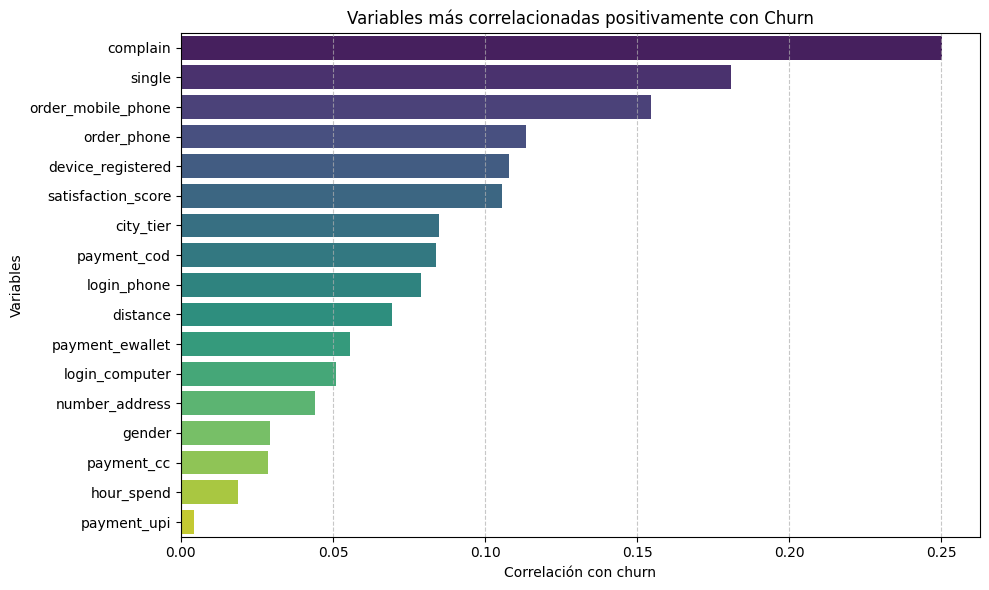

In [35]:
corr_sorted = corr_filtered.sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=corr_sorted.values, y=corr_sorted.index, palette="viridis")
plt.title('Variables más correlacionadas positivamente con Churn')
plt.xlabel('Correlación con churn')
plt.ylabel('Variables')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## CREACIÓN DE MODELOS DE MACHINE LEARNING

# DEFINIMOS VARIABLES X Y Y

In [36]:
X = data_df[cols].values
y = data_df['churn'].values

# ENTRENAMIENTO DE MODELO

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

## REGRESIÓN LOGISTICA

# DIVIDIMOS DATASET EN TRAIN TEST

In [38]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# CREACIÓN DE RED NEURONAL

In [39]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

red = Sequential()
entrada = Dense(units=17,activation='relu')
oculta1 = Dense(units=500,activation='relu')
oculta2 = Dense(units=500,activation='relu')
salida = Dense(units=1,activation='sigmoid')

red.add(entrada)
red.add(oculta1)
red.add(Dropout(0.5))
red.add(oculta2)
red.add(salida)

red

<Sequential name=sequential, built=False>

In [47]:
red.compile(
    #optimizer= tf.keras.optimizers.RMSprop(learning_rate=0.0001),
    optimizer='adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [54]:
model1 = red.fit(X_train,y_train,epochs=3,batch_size=128,validation_data=(X_test,y_test),verbose=1)

Epoch 1/3
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9030 - loss: 0.2445 - val_accuracy: 0.8925 - val_loss: 0.2557
Epoch 2/3
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8969 - loss: 0.2380 - val_accuracy: 0.9014 - val_loss: 0.2520
Epoch 3/3
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9090 - loss: 0.2249 - val_accuracy: 0.9032 - val_loss: 0.2464


In [55]:
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay

y_pred = red.predict(X_test)
y_pred = np.round(y_pred)

score = accuracy_score(y_test,y_pred)
print(f'el accuracy es {score}')

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
el accuracy es 0.9031971580817052


<Figure size 1100x1100 with 0 Axes>

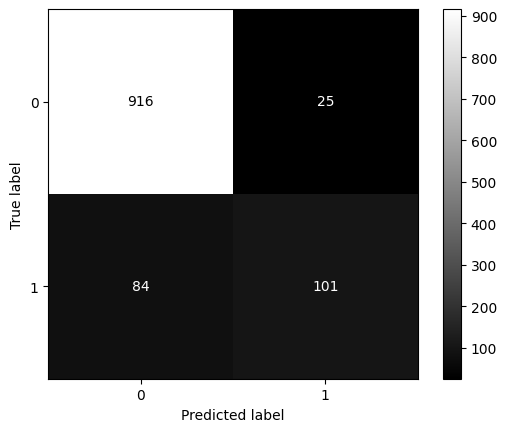

In [56]:
matrix = confusion_matrix(y_test,y_pred)
fig = plt.figure(figsize=(11,11))
cm = matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='gray')
plt.show()

In [57]:
history = red.fit(X_train, y_train, epochs=10, batch_size=128,
                    validation_data=(X_test, y_test), verbose=1)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9129 - loss: 0.2106 - val_accuracy: 0.8943 - val_loss: 0.2470
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9091 - loss: 0.2196 - val_accuracy: 0.9032 - val_loss: 0.2376
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9069 - loss: 0.2165 - val_accuracy: 0.9014 - val_loss: 0.2372
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9121 - loss: 0.2192 - val_accuracy: 0.9023 - val_loss: 0.2394
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9177 - loss: 0.2033 - val_accuracy: 0.9014 - val_loss: 0.2331
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9177 - loss: 0.1965 - val_accuracy: 0.9050 - val_loss: 0.2300
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9160 - loss: 0.2013 - val_accuracy: 0.9050 - val_loss: 0.2333
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9184 - loss: 0.1984 - val_accuracy: 0.9094 - v

In [58]:
def plot_overfitting(history):
    epochs = range(1, len(history.history['loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Pérdida
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['loss'], label='Pérdida de entrenamiento')
    plt.plot(epochs, history.history['val_loss'], label='Pérdida de validación')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.title('Pérdida en entrenamiento vs validación')

    # Precisión
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['accuracy'], label='Precisión de entrenamiento')
    plt.plot(epochs, history.history['val_accuracy'], label='Precisión de validación')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()
    plt.title('Precisión en entrenamiento vs validación')

    plt.show()

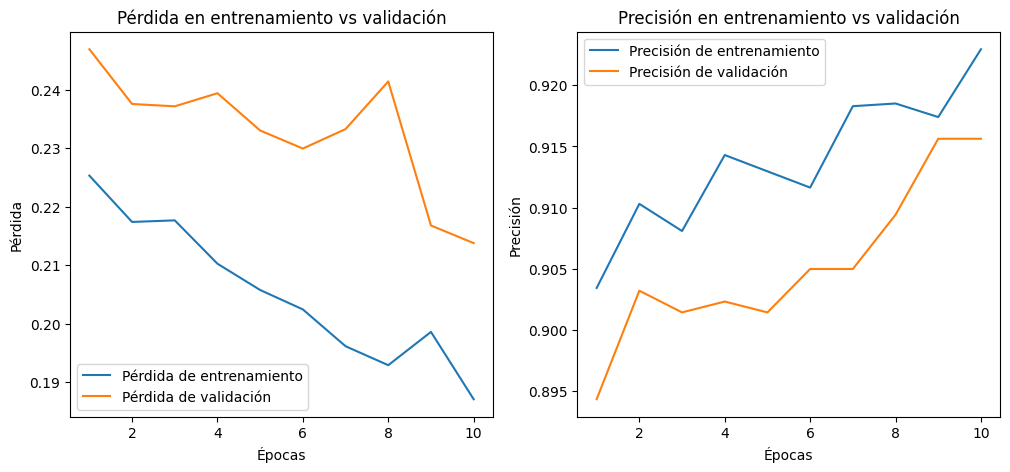

In [59]:
plot_overfitting(history)